# 04. Cell-type-specific differential expression

This notebook compares `Insm1_KO` versus `Control` within annotated retinal cell types.

Primary target cell types:
- `Rod`
- `Cone`
- `Muller_glia`

Important design note: this project has one sample per condition (`TH1 = Control`, `TH2 = Insm1_KO`). Treat these DE results as exploratory cell-level evidence, not as replicated sample-level inference.

## Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
sns.set_style("whitegrid")

/var/folders/bw/h94700p51374zgrbzwg8hrbh0000gn/T/ipykernel_57351/3413846808.py:10: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)


## Resolve project paths

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "samples.csv").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing config/samples.csv")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MARKERS_DIR = PROJECT_ROOT / "results" / "markers"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

INPUT_H5AD = PROCESSED_DIR / "03_annotated.h5ad"
MARKERS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Input object: {INPUT_H5AD}")

Project root: /Users/louis/Desktop/lab/code/scrna/retina_scRNA_TH1_TH2
Input object: /Users/louis/Desktop/lab/code/scrna/retina_scRNA_TH1_TH2/data/processed/03_annotated.h5ad


## Load annotated object

In [3]:
adata = sc.read_h5ad(INPUT_H5AD)
adata

AnnData object with n_obs × n_vars = 37729 × 32286
    obs: 'sample_id', 'condition', 'raw_matrix_dir', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res_0.10', 'leiden_res_0.30', 'leiden_res_0.50', 'score_Rod', 'score_Cone', 'score_Bipolar', 'score_Amacrine', 'score_Muller_glia', 'score_Horizontal', 'score_RGC', 'score_RPE', 'score_Astrocyte', 'score_Microglia', 'score_Endothelial', 'score_Pericyte', 'manual_celltype_annotation'
    var: 'gene_ids', 'feature_types', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'condition_colors', 'hvg', 'leiden_res_0.10', 'leiden_res_0.10_colors', 'leiden_res_0.30', 'lei

In [4]:
CELLTYPE_KEY = "manual_celltype_annotation"
CONDITION_KEY = "condition"
KO_LABEL = "Insm1_KO"
CONTROL_LABEL = "Control"
TARGET_CELLTYPES = ["Rod", "Cone", "Muller_glia"]

pd.crosstab(adata.obs[CELLTYPE_KEY], adata.obs[CONDITION_KEY])

condition,Control,Insm1_KO
manual_celltype_annotation,,
Amacrine,377,734
Astrocyte,6,26
Bipolar,1889,3985
Cone,515,1007
Endothelial,60,59
Horizontal,12,15
Microglia,61,202
Muller_glia,1254,4090
Pericyte,33,36


## Helper functions

In [5]:
def sanitize_label(label: str) -> str:
    return label.replace(" ", "_").replace("/", "_")


def run_celltype_de(adata, cell_type):
    subset = adata[
        adata.obs[CELLTYPE_KEY].astype(str).eq(cell_type)
        & adata.obs[CONDITION_KEY].astype(str).isin([CONTROL_LABEL, KO_LABEL])
    ].copy()

    counts = subset.obs[CONDITION_KEY].value_counts()
    print(f"{cell_type}: {dict(counts)}")

    if not {CONTROL_LABEL, KO_LABEL}.issubset(set(counts.index)):
        raise ValueError(f"{cell_type} does not contain both conditions")

    sc.tl.rank_genes_groups(
        subset,
        groupby=CONDITION_KEY,
        groups=[KO_LABEL],
        reference=CONTROL_LABEL,
        method="wilcoxon",
        pts=True,
        use_raw=False,
    )

    de = sc.get.rank_genes_groups_df(subset, group=KO_LABEL)
    de = de.replace([np.inf, -np.inf], np.nan)
    de = de.dropna(subset=["names", "logfoldchanges", "pvals_adj"])
    de["cell_type"] = cell_type
    de["comparison"] = f"{KO_LABEL}_vs_{CONTROL_LABEL}"
    de["neg_log10_padj"] = -np.log10(de["pvals_adj"].clip(lower=1e-300))

    return subset, de


def classify_de(de, logfc_threshold=1.0, padj_threshold=0.05):
    de = de.copy()
    de["regulation"] = "Not significant"
    de.loc[
        (de["logfoldchanges"] >= logfc_threshold) & (de["pvals_adj"] < padj_threshold),
        "regulation",
    ] = "Up in KO"
    de.loc[
        (de["logfoldchanges"] <= -logfc_threshold) & (de["pvals_adj"] < padj_threshold),
        "regulation",
    ] = "Down in KO"
    return de


def plot_volcano(de, cell_type, label_genes=None, logfc_threshold=1.0, padj_threshold=0.05):
    if label_genes is None:
        label_genes = []

    de = classify_de(de, logfc_threshold=logfc_threshold, padj_threshold=padj_threshold)

    palette = {
        "Up in KO": "#d73027",
        "Down in KO": "#4575b4",
        "Not significant": "#9e9e9e",
    }

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=de,
        x="logfoldchanges",
        y="neg_log10_padj",
        hue="regulation",
        palette=palette,
        s=12,
        linewidth=0,
        alpha=0.75,
        ax=ax,
    )

    ax.axvline(logfc_threshold, color="black", linestyle="--", linewidth=0.8)
    ax.axvline(-logfc_threshold, color="black", linestyle="--", linewidth=0.8)
    ax.axhline(-np.log10(padj_threshold), color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"{cell_type}: {KO_LABEL} vs {CONTROL_LABEL}")
    ax.set_xlabel("log fold change")
    ax.set_ylabel("-log10 adjusted p-value")

    label_df = de[de["names"].isin(label_genes)].copy()
    for _, row in label_df.iterrows():
        ax.text(
            row["logfoldchanges"],
            row["neg_log10_padj"],
            row["names"],
            fontsize=8,
        )

    ax.legend(title="", loc="upper right")
    plt.tight_layout()

    out_path = FIGURES_DIR / f"04_volcano_{sanitize_label(cell_type)}.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved volcano plot: {out_path}")

## Run DE for target cell types

Positive `logfoldchanges` means higher expression in `Insm1_KO` than `Control` within that cell type.

Rod: {'Insm1_KO': np.int64(13919), 'Control': np.int64(9250)}


/Users/louis/Desktop/lab/code/scrna/.venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


Saved DE table: /Users/louis/Desktop/lab/code/scrna/retina_scRNA_TH1_TH2/results/markers/04_de_Rod_Insm1_KO_vs_Control.csv


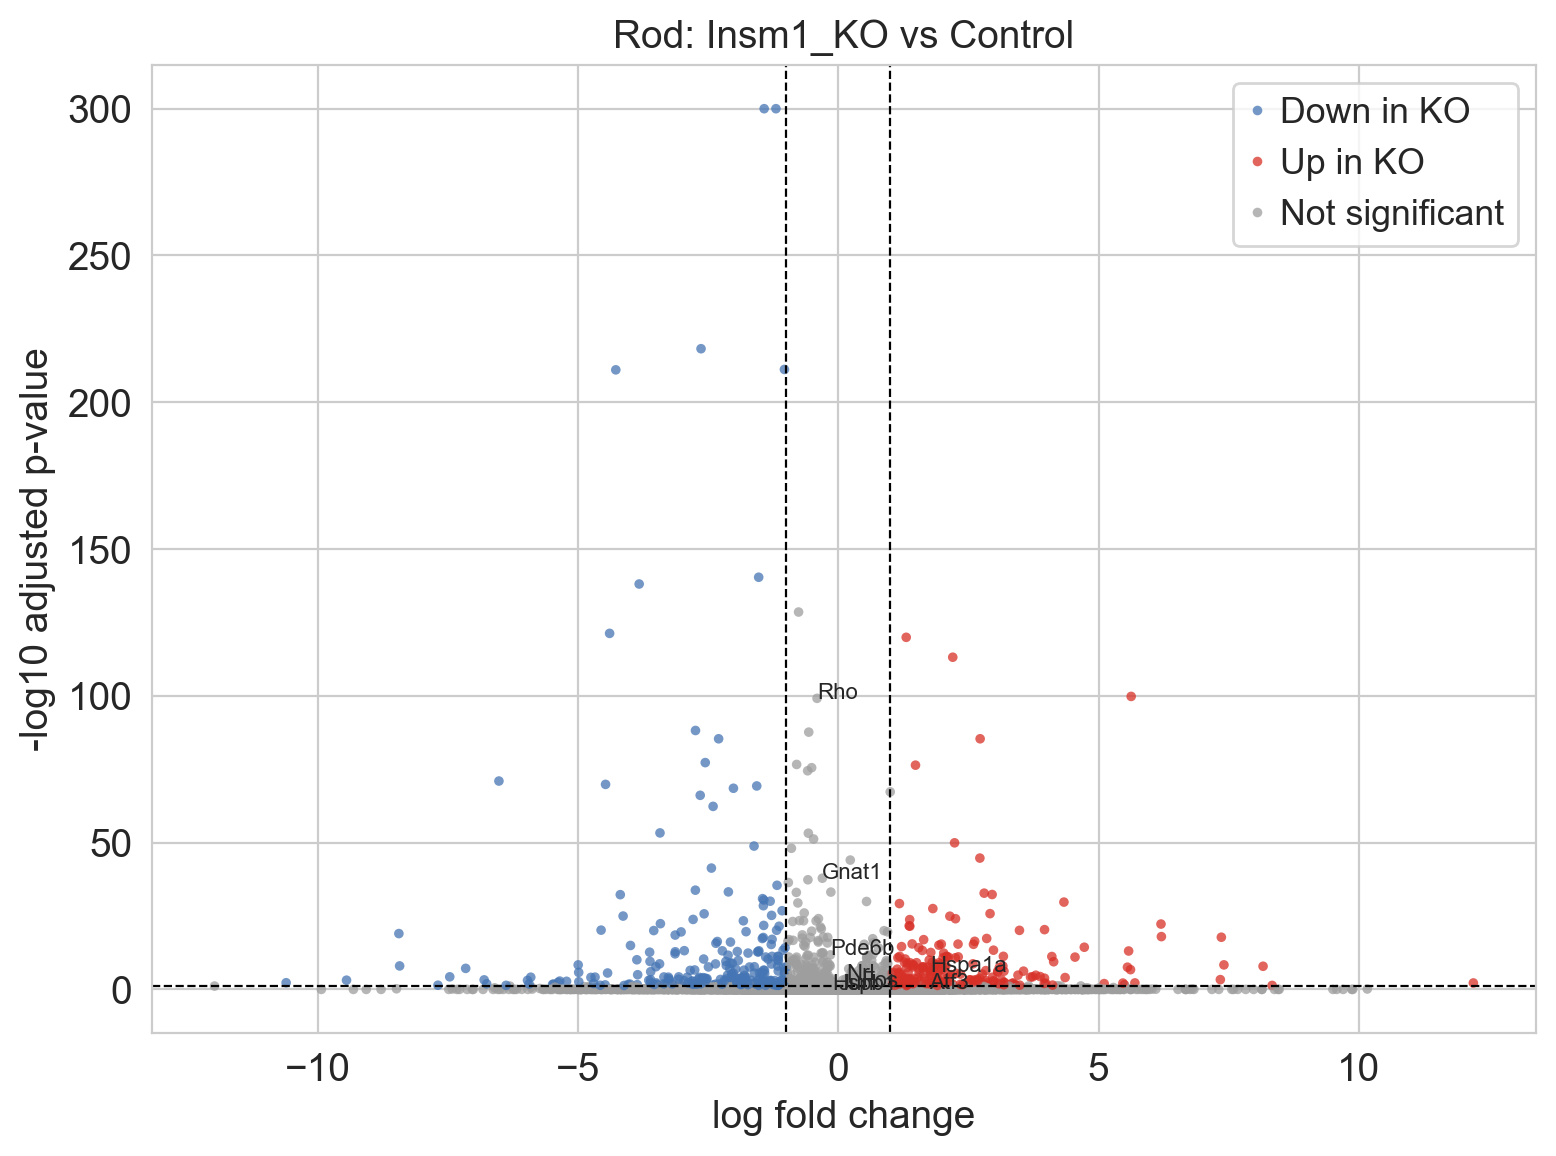

Saved volcano plot: /Users/louis/Desktop/lab/code/scrna/retina_scRNA_TH1_TH2/results/figures/04_volcano_Rod.png
Cone: {'Insm1_KO': np.int64(1007), 'Control': np.int64(515)}


/Users/louis/Desktop/lab/code/scrna/.venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


Saved DE table: /Users/louis/Desktop/lab/code/scrna/retina_scRNA_TH1_TH2/results/markers/04_de_Cone_Insm1_KO_vs_Control.csv


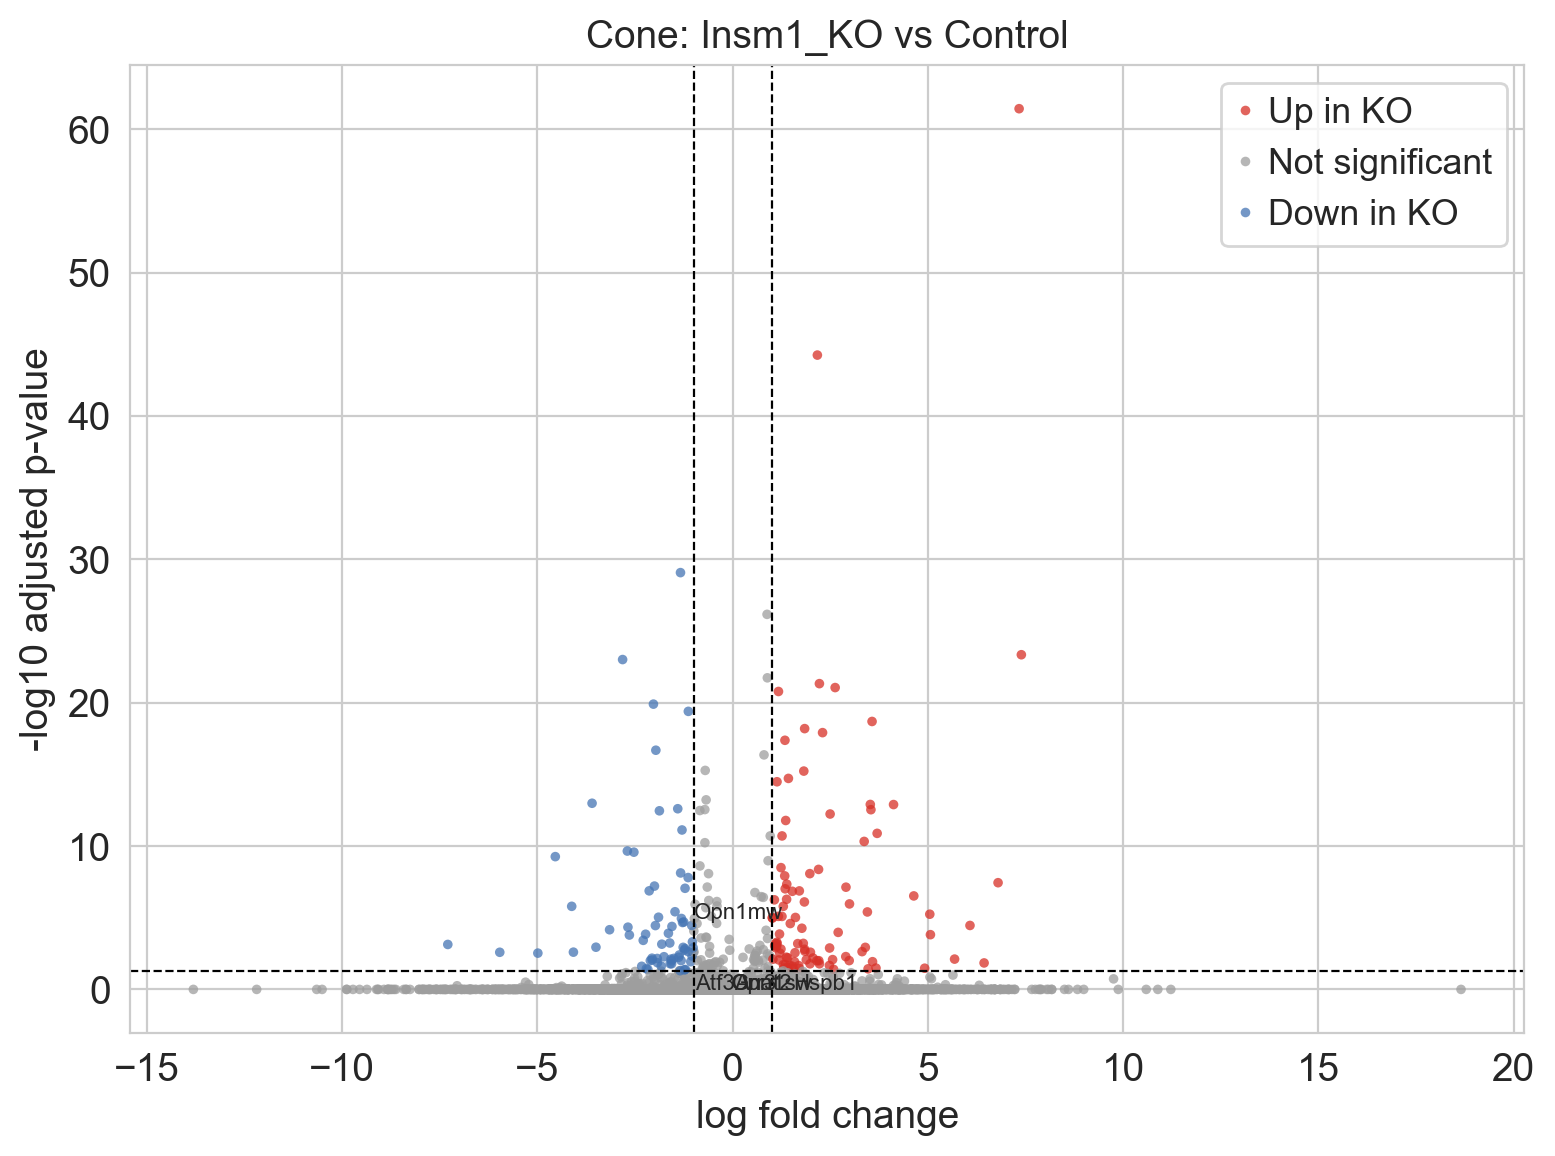

Saved volcano plot: /Users/louis/Desktop/lab/code/scrna/retina_scRNA_TH1_TH2/results/figures/04_volcano_Cone.png
Muller_glia: {'Insm1_KO': np.int64(4090), 'Control': np.int64(1254)}


/Users/louis/Desktop/lab/code/scrna/.venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


Saved DE table: /Users/louis/Desktop/lab/code/scrna/retina_scRNA_TH1_TH2/results/markers/04_de_Muller_glia_Insm1_KO_vs_Control.csv


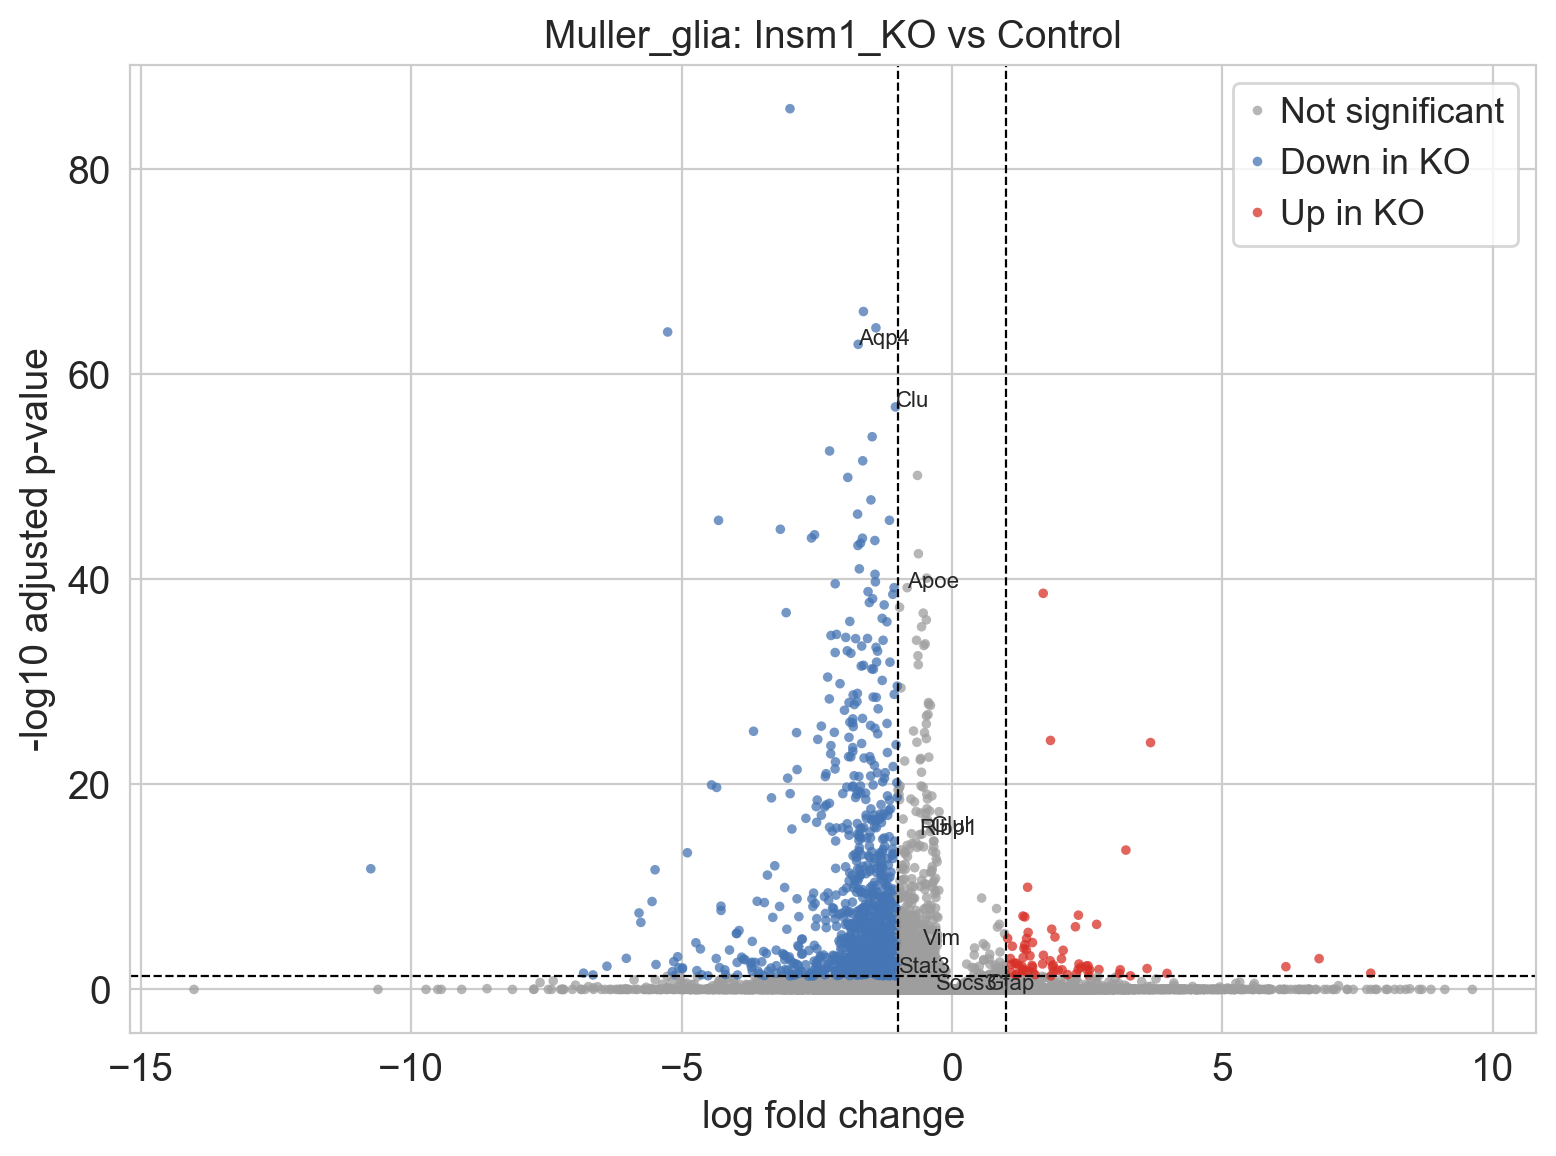

Saved volcano plot: /Users/louis/Desktop/lab/code/scrna/retina_scRNA_TH1_TH2/results/figures/04_volcano_Muller_glia.png


In [6]:
genes_to_label = {
    "Rod": ["Rho", "Nrl", "Gnat1", "Pde6b", "Fos", "Jun", "Atf3", "Hspa1a", "Hspb1"],
    "Cone": ["Arr3", "Opn1mw", "Opn1sw", "Gnat2", "Fos", "Jun", "Atf3", "Hspb1"],
    "Muller_glia": ["Rlbp1", "Glul", "Aqp4", "Gfap", "Vim", "Clu", "Apoe", "Lcn2", "Socs3", "Stat3"],
}

de_results = {}
subsets = {}

for cell_type in TARGET_CELLTYPES:
    subset, de = run_celltype_de(adata, cell_type)
    de = classify_de(de)
    subsets[cell_type] = subset
    de_results[cell_type] = de

    out_csv = MARKERS_DIR / f"04_de_{sanitize_label(cell_type)}_{KO_LABEL}_vs_{CONTROL_LABEL}.csv"
    de.to_csv(out_csv, index=False)
    print(f"Saved DE table: {out_csv}")

    plot_volcano(de, cell_type, label_genes=genes_to_label.get(cell_type, []))

## Summarize significant DE genes

In [7]:
de_summary = []

for cell_type, de in de_results.items():
    de_summary.append({
        "cell_type": cell_type,
        "n_cells_control": int((subsets[cell_type].obs[CONDITION_KEY] == CONTROL_LABEL).sum()),
        "n_cells_ko": int((subsets[cell_type].obs[CONDITION_KEY] == KO_LABEL).sum()),
        "n_up_in_ko": int((de["regulation"] == "Up in KO").sum()),
        "n_down_in_ko": int((de["regulation"] == "Down in KO").sum()),
        "n_tested_genes": int(de.shape[0]),
    })

de_summary = pd.DataFrame(de_summary)
de_summary.to_csv(MARKERS_DIR / "04_de_summary.csv", index=False)
de_summary

,cell_type,n_cells_control,n_cells_ko,n_up_in_ko,n_down_in_ko,n_tested_genes
0,Rod,9250,13919,208,250,29513
1,Cone,515,1007,98,69,26833
2,Muller_glia,1254,4090,70,1000,28531


## Inspect top genes

In [8]:
top_tables = []

for cell_type, de in de_results.items():
    up = de[de["regulation"] == "Up in KO"].sort_values("pvals_adj").head(20).copy()
    down = de[de["regulation"] == "Down in KO"].sort_values("pvals_adj").head(20).copy()
    up["direction"] = "Up in KO"
    down["direction"] = "Down in KO"
    top_tables.append(pd.concat([up, down], ignore_index=True))

top_de_genes = pd.concat(top_tables, ignore_index=True)
top_de_genes.to_csv(MARKERS_DIR / "04_top_de_genes.csv", index=False)

preferred_columns = [
    "cell_type", "direction", "names", "logfoldchanges", "pvals_adj",
    "pts", "pts_rest", "pct_nz_group", "pct_nz_reference",
]
display_columns = [col for col in preferred_columns if col in top_de_genes.columns]

top_de_genes[display_columns]

,cell_type,direction,names,logfoldchanges,pvals_adj,pct_nz_group
0,Rod,Up in KO,Samd11,1.305099,1.165661e-120,1.0
1,Rod,Up in KO,Vax2os,2.199292,6.979991e-114,1.0
2,Rod,Up in KO,Krt18,5.627131,1.578635e-100,1.0
3,Rod,Up in KO,Mir124-2hg,2.725223,4.229311e-86,1.0
4,Rod,Up in KO,Rsrp1,1.483203,4.114916e-77,1.0
...,...,...,...,...,...,...
115,Muller_glia,Down in KO,Epha4,-2.541074,4.520198e-45,1.0
116,Muller_glia,Down in KO,Cd44,-2.597396,9.193299e-45,1.0
117,Muller_glia,Down in KO,Spon1,-1.655156,9.717206e-45,1.0
118,Muller_glia,Down in KO,Cd81,-1.424961,1.638381e-44,1.0


## Heatmap of selected DE genes

This plots a small selected set of significant genes per cell type. It is intended for review, not as a publication figure.

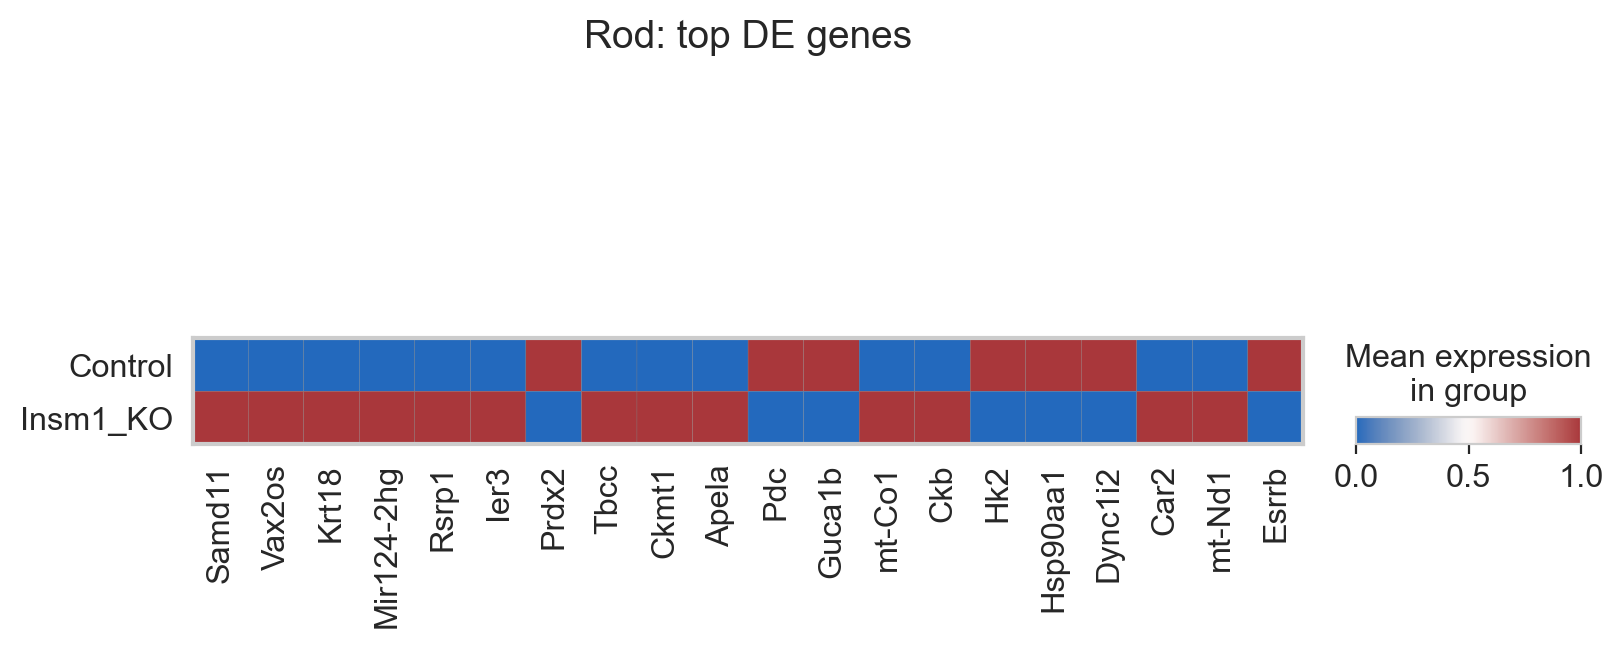

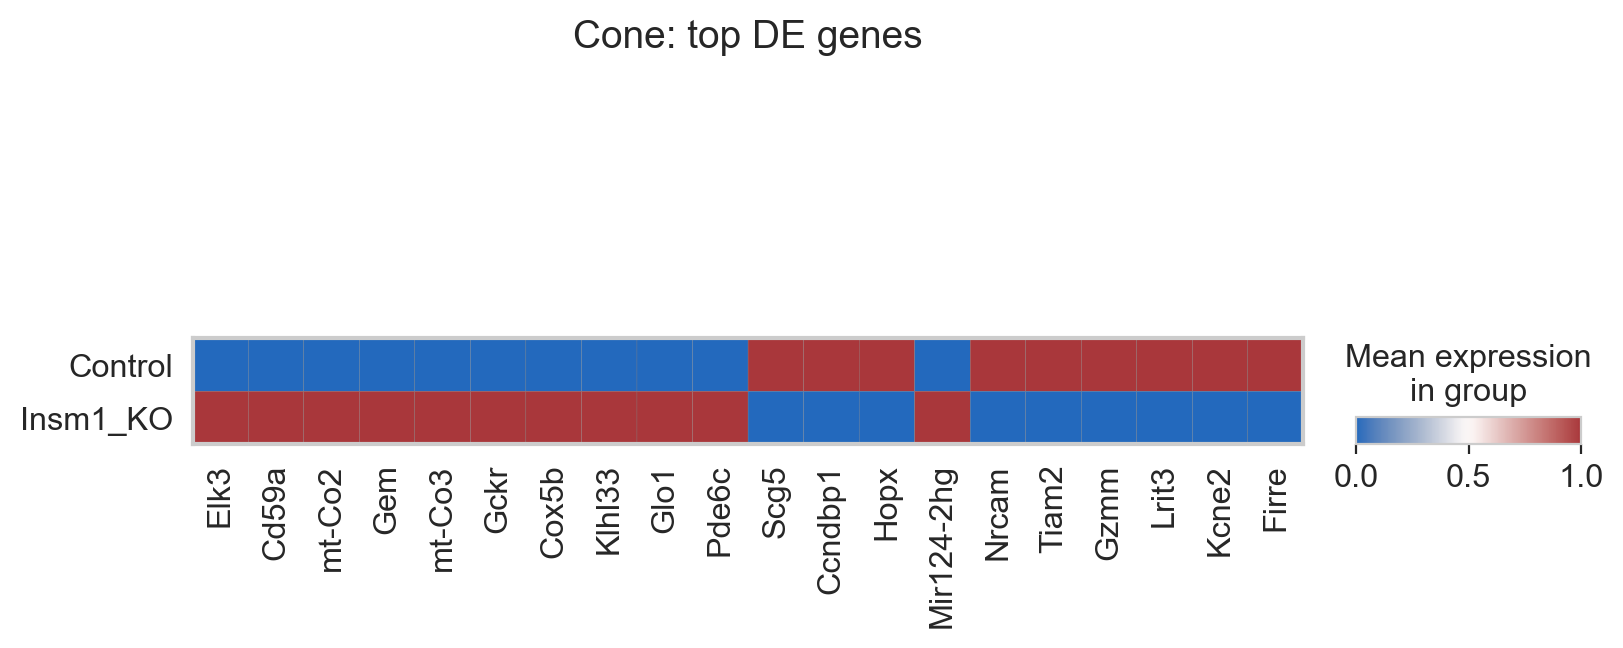

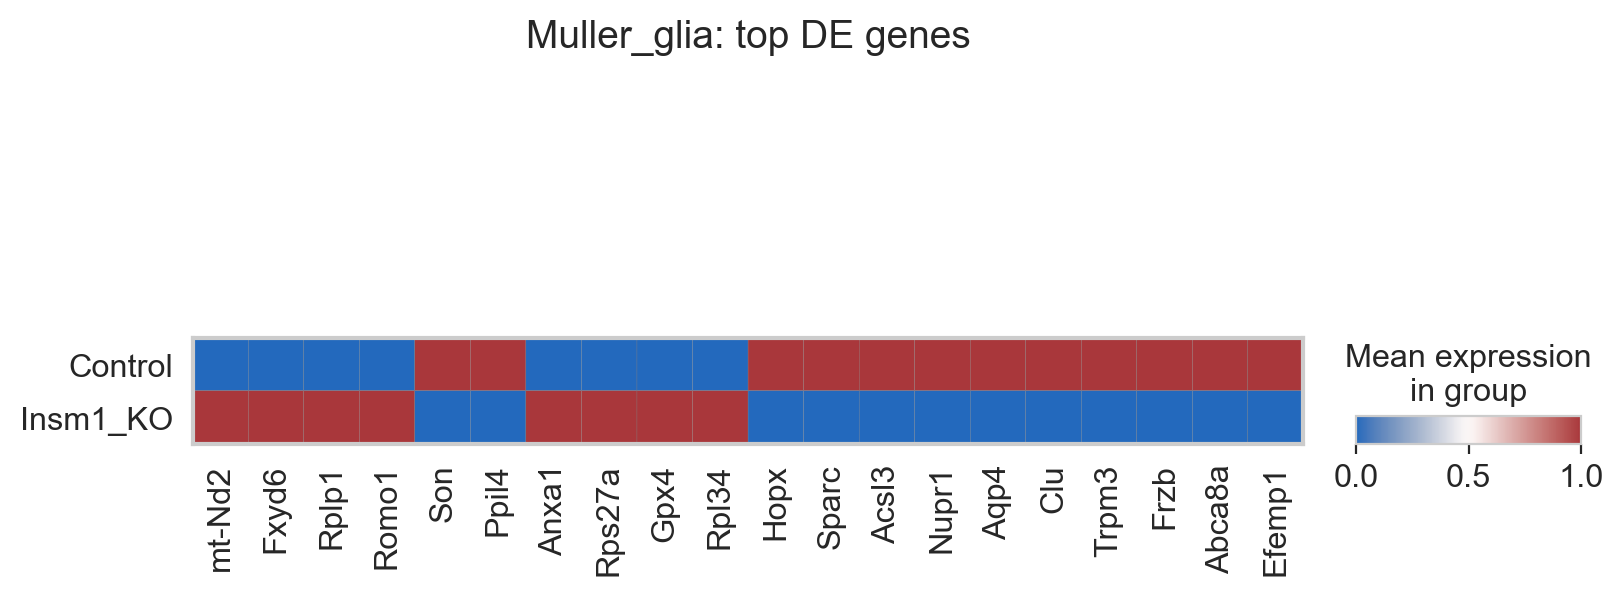

In [9]:
for cell_type, subset in subsets.items():
    de = de_results[cell_type]
    selected_genes = (
        pd.concat([
            de[de["regulation"] == "Up in KO"].sort_values("pvals_adj").head(10),
            de[de["regulation"] == "Down in KO"].sort_values("pvals_adj").head(10),
        ])
        ["names"]
        .drop_duplicates()
        .tolist()
    )

    if not selected_genes:
        print(f"{cell_type}: no significant selected genes to plot")
        continue

    sc.pl.matrixplot(
        subset,
        var_names=selected_genes,
        groupby=CONDITION_KEY,
        standard_scale="var",
        title=f"{cell_type}: top DE genes",
        cmap="vlag",
    )

## Inspect genes related to Muller glia activation and retinal stress

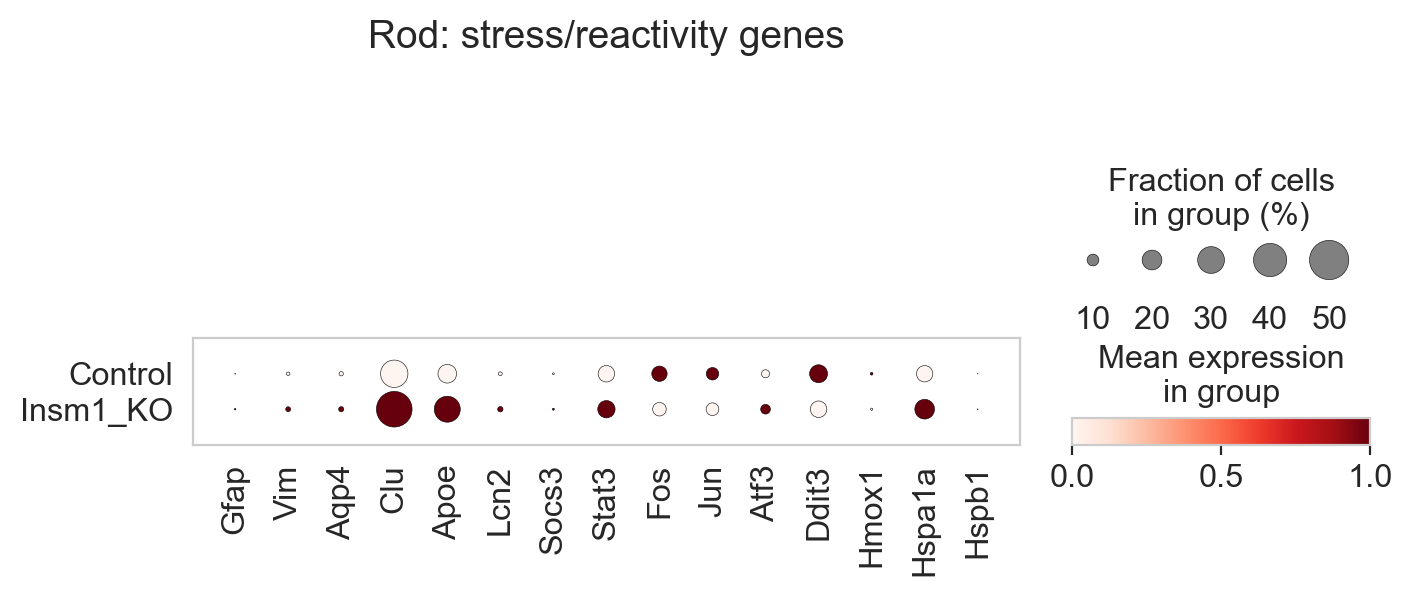

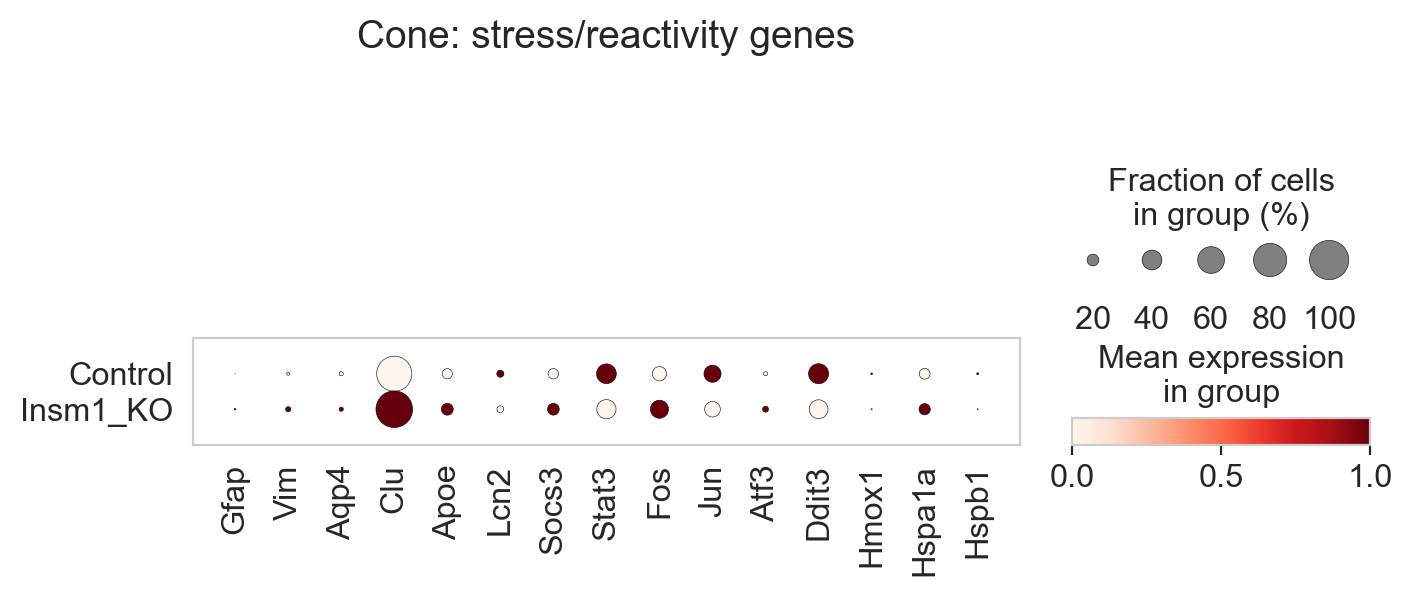

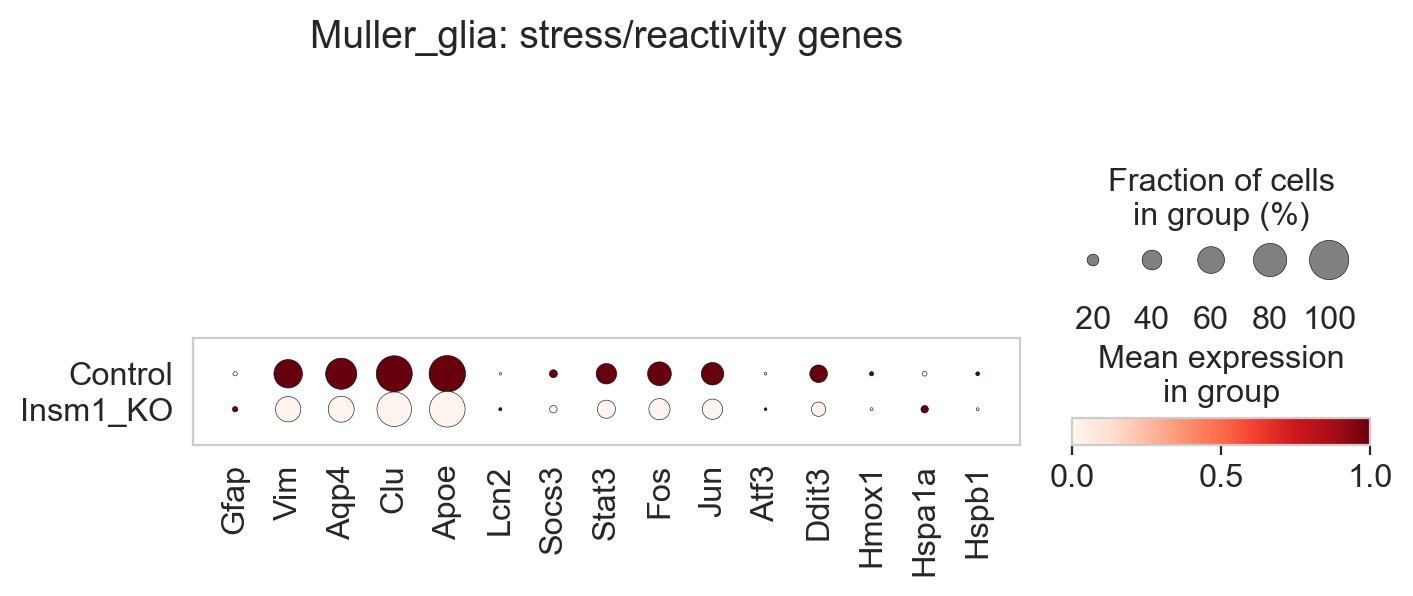

In [10]:
stress_genes = [
    "Gfap", "Vim", "Aqp4", "Clu", "Apoe", "Lcn2", "Socs3", "Stat3",
    "Fos", "Jun", "Atf3", "Ddit3", "Hmox1", "Hspa1a", "Hspb1",
]
stress_genes = [gene for gene in stress_genes if gene in adata.var_names]

for cell_type, subset in subsets.items():
    available = [gene for gene in stress_genes if gene in subset.var_names]
    if not available:
        continue
    sc.pl.dotplot(
        subset,
        var_names=available,
        groupby=CONDITION_KEY,
        standard_scale="var",
        title=f"{cell_type}: stress/reactivity genes",
    )

## Combine all DE results

In [11]:
all_de = pd.concat(de_results.values(), ignore_index=True)
all_de.to_csv(MARKERS_DIR / f"04_de_all_target_celltypes_{KO_LABEL}_vs_{CONTROL_LABEL}.csv", index=False)
all_de.head()

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,cell_type,comparison,neg_log10_padj,regulation
0,mt-Co1,31.847372,-2.636884,1.431337e-222,5.776517e-219,1.0,Rod,Insm1_KO_vs_Control,218.238334,Down in KO
1,Ckb,31.329969,-1.034633,1.823743e-215,6.542375e-212,1.0,Rod,Insm1_KO_vs_Control,211.184265,Down in KO
2,Car2,23.782564,-4.393436,5.060334e-125,5.270257e-122,1.0,Rod,Insm1_KO_vs_Control,121.278168,Down in KO
3,Samd11,23.650904,1.305099,1.155336e-123,1.165661e-120,1.0,Rod,Insm1_KO_vs_Control,119.933428,Up in KO
4,Vax2os,22.977743,2.199292,7.782930e-117,6.979991e-114,1.0,Rod,Insm1_KO_vs_Control,113.156145,Up in KO


## Interpretation notes

- Positive `logfoldchanges` means higher in `Insm1_KO`.
- Negative `logfoldchanges` means lower in `Insm1_KO`.
- `pts` is the fraction of KO cells expressing the gene in this comparison.
- `pts_rest` is the fraction of control cells expressing the gene.
- With one sample per condition, these p-values are cell-level exploratory statistics and can be overconfident because cells are not independent biological replicates.